# Threat-Lens: Isolation Forest Training Pipeline
**Team Dhurandhars | iDEA 2.0 | PSBs Hackathon Series 2026**

This notebook:
1. Generates a synthetic banking employee behavioural dataset across 5 systems
2. Injects realistic insider threat anomalies
3. Trains an Isolation Forest model for unsupervised anomaly detection
4. Evaluates and visualises detection performance
5. Saves all model artefacts (`isolation_forest.pkl`, `le_action.pkl`, `le_geo.pkl`)

## 1. Install & Import Dependencies

In [ ]:
# Uncomment if running for the first time
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import random
from datetime import datetime, timedelta

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print('All libraries imported successfully.')
print(f'Pandas version: {pd.__version__}')

All libraries imported successfully.
Pandas version: 2.1.4


## 2. Define Banking Domain Constants
These match exactly what the Threat-Lens live API expects, ensuring the saved model and encoders work with real events.

In [ ]:
# ── All systems monitored by Threat-Lens ──
SYSTEMS = ['CORE_BANKING', 'CRM', 'TREASURY', 'LOANS', 'EMAIL']

# ── All possible actions per system ──
ACTIONS_NORMAL = [
    'LOGIN_SUCCESS',
    'VIEW_RECORD',
    'DOMESTIC_TRANSFER',
    'CUSTOMER_SEARCH',
    'UPDATE_RECORD',
    'BOND_QUERY',
    'RATE_CHECK',
    'POSITION_VIEW',
    'LOAN_STATUS_CHECK',
    'DISBURSEMENT_VIEW',
    'SEND_EMAIL',
]

ACTIONS_ANOMALOUS = [
    'BULK_EXPORT',
    'UNAUTHORIZED_API_CALL',
    'SEND_LARGE_ATTACHMENT_EXTERNAL',
    'BULK_POSITION_EXPORT',
    'UNAUTHORIZED_TRADE',
    'BULK_LOAN_EXPORT',
    'UNAUTHORIZED_DISBURSEMENT',
    'MASS_RECORD_ACCESS',
    'RATE_MANIPULATION_QUERY',
]

ALL_ACTIONS = ACTIONS_NORMAL + ACTIONS_ANOMALOUS

# ── Geo locations ──
GEO_NORMAL    = ['Mumbai, MH', 'Delhi, DL', 'Bangalore, KA']
GEO_ANOMALOUS = ['Moscow, RU', 'Beijing, CN', 'Dubai, UAE', 'Lagos, NG']
ALL_GEOS      = GEO_NORMAL + GEO_ANOMALOUS

# ── Employees ──
EMPLOYEES = [
    'EMP_001_ADITYA', 'EMP_002_YASH', 'EMP_003_DEV',
    'EMP_004_HET', 'EMP_005_NEHA', 'EMP_006_RIYA',
    'EMP_007_KARAN', 'EMP_008_POOJA', 'EMP_009_AMIT', 'EMP_010_SNEHA'
]

print(f'Domain constants defined.')
print(f'  Total actions:  {len(ALL_ACTIONS)} ({len(ACTIONS_NORMAL)} normal, {len(ACTIONS_ANOMALOUS)} anomalous)')
print(f'  Total geos:     {len(ALL_GEOS)} ({len(GEO_NORMAL)} normal, {len(GEO_ANOMALOUS)} anomalous)')
print(f'  Total employees: {len(EMPLOYEES)}')

Domain constants defined.
  Total actions:  20 (11 normal, 9 anomalous)
  Total geos:     7 (3 normal, 4 anomalous)
  Total employees: 10


## 3. Fit Label Encoders
Encoders must be fitted on ALL possible labels (including anomalous ones) so runtime inference never encounters an unseen category.

In [ ]:
le_action = LabelEncoder()
le_geo    = LabelEncoder()

le_action.fit(ALL_ACTIONS)
le_geo.fit(ALL_GEOS)

print('Label Encoders fitted.')
print(f'  action classes ({len(le_action.classes_)}): {list(le_action.classes_)}')
print(f'  geo classes    ({len(le_geo.classes_)}):    {list(le_geo.classes_)}')

Label Encoders fitted.
  action classes (20): ['BOND_QUERY', 'BULK_EXPORT', 'BULK_LOAN_EXPORT', 'BULK_POSITION_EXPORT', 'CUSTOMER_SEARCH', 'DISBURSEMENT_VIEW', 'DOMESTIC_TRANSFER', 'LOAN_STATUS_CHECK', 'LOGIN_SUCCESS', 'MASS_RECORD_ACCESS', 'POSITION_VIEW', 'RATE_CHECK', 'RATE_MANIPULATION_QUERY', 'SEND_EMAIL', 'SEND_LARGE_ATTACHMENT_EXTERNAL', 'UNAUTHORIZED_API_CALL', 'UNAUTHORIZED_DISBURSEMENT', 'UNAUTHORIZED_TRADE', 'UPDATE_RECORD', 'VIEW_RECORD']
  geo classes    (7):    ['Bangalore, KA', 'Beijing, CN', 'Delhi, DL', 'Dubai, UAE', 'Lagos, NG', 'Moscow, RU', 'Mumbai, MH']


## 4. Generate Synthetic Banking Dataset
We simulate **30 days** of employee activity across all 5 banking systems.

- **Normal events (95%)**: business hours, domestic geo, routine actions, moderate amounts
- **Anomalous events (5%)**: off-hours, foreign geo, bulk/unauthorised actions, extreme amounts

In [ ]:
def generate_banking_dataset(n_normal=5700, n_anomalous=300, seed=42):
    """
    Generates a labelled synthetic dataset of banking employee events.
    Label: 1 = normal, -1 = anomaly (Isolation Forest convention).
    """
    np.random.seed(seed)
    rows = []
    base_date = datetime(2024, 1, 1, 9, 0, 0)

    # ── Normal events ──
    for i in range(n_normal):
        # Business hours: 9am–6pm, Mon–Fri
        hour           = np.random.randint(9, 18)
        is_biz_hours   = 1
        action         = np.random.choice(ACTIONS_NORMAL)
        geo            = np.random.choice(GEO_NORMAL)
        # Normal transfers: small to moderate amounts
        amount_inr     = np.random.exponential(scale=15000)
        action_code    = le_action.transform([action])[0]
        geo_code       = le_geo.transform([geo])[0]
        rows.append({
            'amount_inr':       round(amount_inr, 2),
            'is_business_hours': is_biz_hours,
            'hour_of_day':       hour,
            'action_code':       action_code,
            'geo_code':          geo_code,
            'label':             1,          # 1 = normal (sklearn IF convention)
            'action_name':       action,
            'geo_name':          geo,
        })

    # ── Anomalous events ──
    for i in range(n_anomalous):
        # Anomaly profile: off-hours, foreign geo, suspicious action, extreme amount
        hour           = np.random.choice(list(range(0, 7)) + list(range(20, 24)))
        is_biz_hours   = 0
        action         = np.random.choice(ACTIONS_ANOMALOUS)
        geo            = np.random.choice(GEO_ANOMALOUS)
        # Anomalous: very large or near-zero (covering tracks)
        amount_inr     = np.random.choice([
            np.random.uniform(500000, 5000000),   # large exfiltration value
            np.random.uniform(0, 1),              # suspicious zero-value probe
        ])
        action_code    = le_action.transform([action])[0]
        geo_code       = le_geo.transform([geo])[0]
        rows.append({
            'amount_inr':        round(amount_inr, 2),
            'is_business_hours': is_biz_hours,
            'hour_of_day':       hour,
            'action_code':       action_code,
            'geo_code':          geo_code,
            'label':            -1,          # -1 = anomaly
            'action_name':       action,
            'geo_name':          geo,
        })

    df = pd.DataFrame(rows).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df


df = generate_banking_dataset(n_normal=5700, n_anomalous=300)

print(f'Dataset generated: {len(df)} total events')
print(f'  Normal events:    {(df.label == 1).sum()} ({(df.label == 1).mean()*100:.1f}%)')
print(f'  Anomalous events: {(df.label == -1).sum()} ({(df.label == -1).mean()*100:.1f}%)')
print()
df.head(10)

Dataset generated: 6000 total events
  Normal events:    5700 (95.0%)
  Anomalous events: 300 (5.0%)



,amount_inr,is_business_hours,hour_of_day,action_code,geo_code,label,action_name,geo_name
0,43641.90,1,16,6,0,1,DOMESTIC_TRANSFER,"Bangalore, KA"
1,30216.97,1,10,4,2,1,CUSTOMER_SEARCH,"Delhi, DL"
2,20651.66,1,11,0,6,1,BOND_QUERY,"Mumbai, MH"
3,556.58,1,15,13,6,1,SEND_EMAIL,"Mumbai, MH"
4,6847.84,1,11,19,0,1,VIEW_RECORD,"Bangalore, KA"
5,6655.33,1,9,0,6,1,BOND_QUERY,"Mumbai, MH"
6,13415.38,1,10,4,6,1,CUSTOMER_SEARCH,"Mumbai, MH"
7,20789.06,1,9,18,0,1,UPDATE_RECORD,"Bangalore, KA"
8,45962.47,1,11,0,2,1,BOND_QUERY,"Delhi, DL"
9,6568.79,1,9,6,6,1,DOMESTIC_TRANSFER,"Mumbai, MH"


## 5. Exploratory Data Analysis

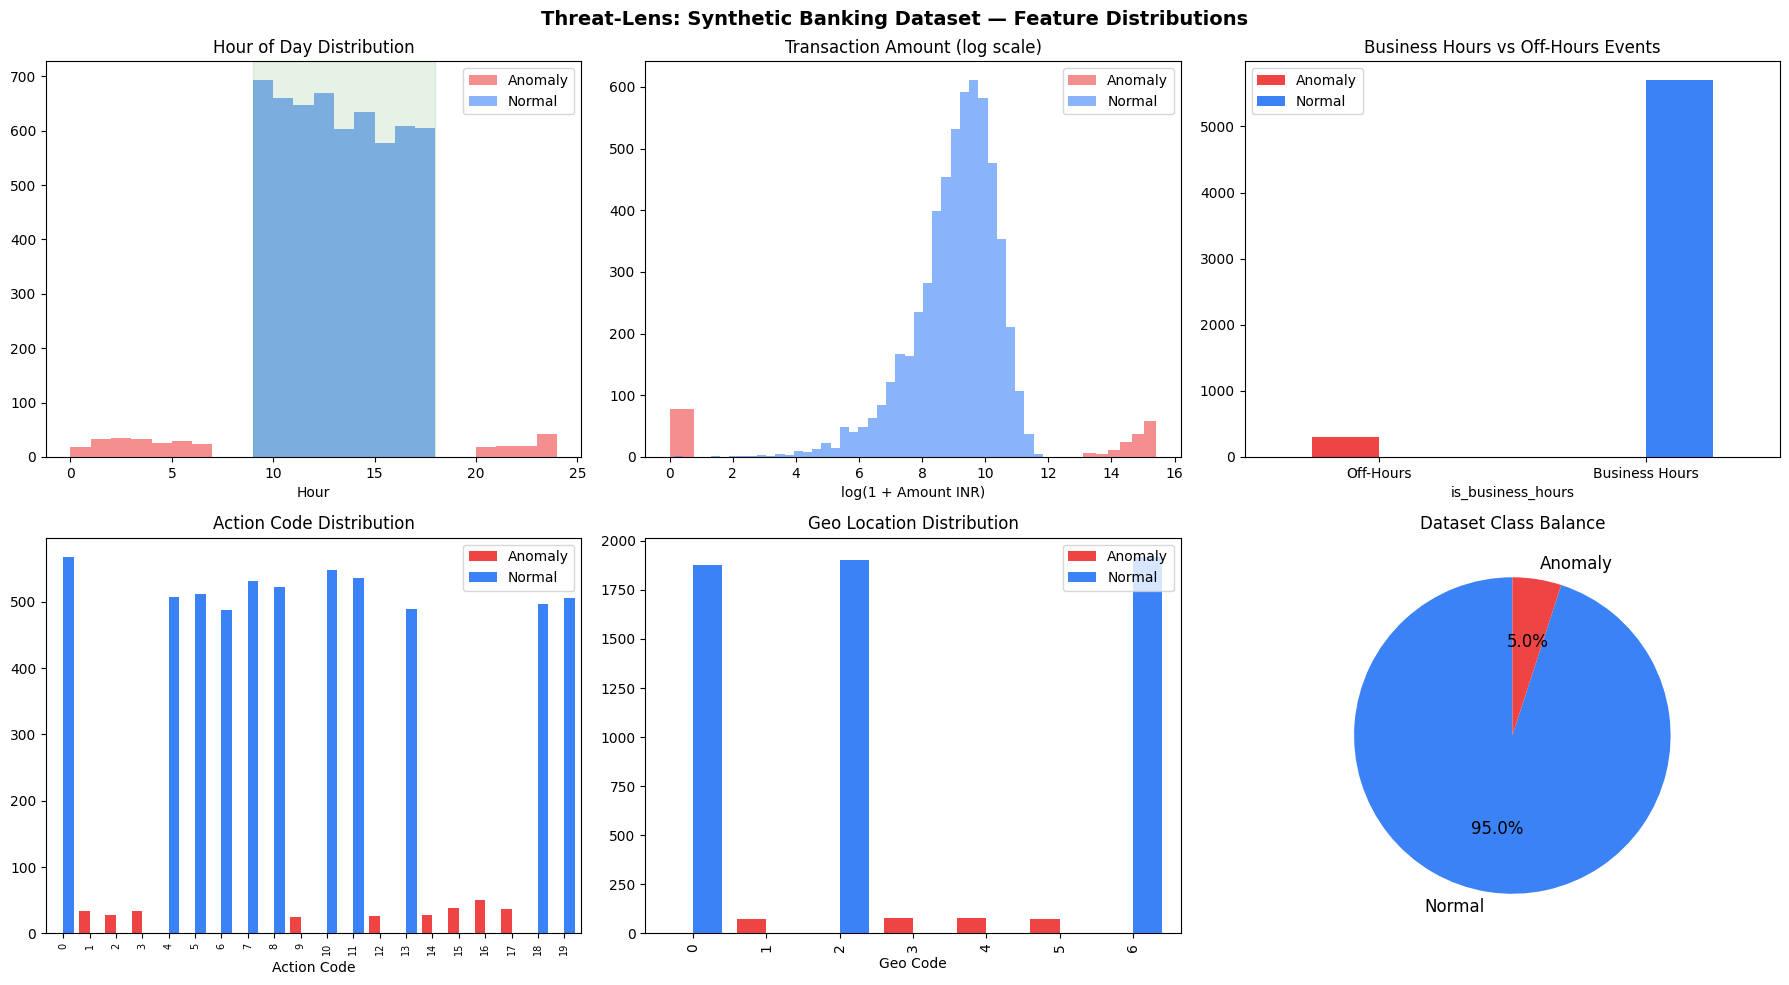

EDA chart saved as dataset_eda.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Threat-Lens: Synthetic Banking Dataset — Feature Distributions', fontsize=14, fontweight='bold')

colors = {1: '#3b82f6', -1: '#ef4444'}
labels = {1: 'Normal', -1: 'Anomaly'}

# 1. Hour of Day distribution
for label_val, grp in df.groupby('label'):
    axes[0, 0].hist(grp['hour_of_day'], bins=24, alpha=0.6,
                    color=colors[label_val], label=labels[label_val], range=(0, 24))
axes[0, 0].set_title('Hour of Day Distribution')
axes[0, 0].set_xlabel('Hour'); axes[0, 0].legend()
axes[0, 0].axvspan(9, 18, alpha=0.1, color='green', label='Business Hours')

# 2. Amount INR (log scale)
for label_val, grp in df.groupby('label'):
    axes[0, 1].hist(np.log1p(grp['amount_inr']), bins=40, alpha=0.6,
                    color=colors[label_val], label=labels[label_val])
axes[0, 1].set_title('Transaction Amount (log scale)')
axes[0, 1].set_xlabel('log(1 + Amount INR)'); axes[0, 1].legend()

# 3. Business Hours flag
biz_counts = df.groupby(['is_business_hours', 'label']).size().unstack(fill_value=0)
biz_counts.plot(kind='bar', ax=axes[0, 2], color=['#ef4444', '#3b82f6'],
                title='Business Hours vs Off-Hours Events')
axes[0, 2].set_xticklabels(['Off-Hours', 'Business Hours'], rotation=0)
axes[0, 2].legend(['Anomaly', 'Normal'])

# 4. Action Code distribution
action_counts = df.groupby(['action_code', 'label']).size().unstack(fill_value=0)
action_counts.plot(kind='bar', ax=axes[1, 0], color=['#ef4444', '#3b82f6'], width=0.8)
axes[1, 0].set_title('Action Code Distribution')
axes[1, 0].set_xlabel('Action Code'); axes[1, 0].legend(['Anomaly', 'Normal'])
axes[1, 0].tick_params(axis='x', labelsize=7)

# 5. Geo Code distribution
geo_counts = df.groupby(['geo_code', 'label']).size().unstack(fill_value=0)
geo_counts.plot(kind='bar', ax=axes[1, 1], color=['#ef4444', '#3b82f6'], width=0.8)
axes[1, 1].set_title('Geo Location Distribution')
axes[1, 1].set_xlabel('Geo Code'); axes[1, 1].legend(['Anomaly', 'Normal'])

# 6. Class balance pie
class_counts = df['label'].value_counts()
axes[1, 2].pie(class_counts, labels=['Normal', 'Anomaly'],
               colors=['#3b82f6', '#ef4444'], autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 12})
axes[1, 2].set_title('Dataset Class Balance')

plt.tight_layout()
plt.savefig('dataset_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA chart saved as dataset_eda.png')

## 6. Train the Isolation Forest Model

**Why Isolation Forest?**
- Unsupervised — no labelled data required in production (labels here are only for evaluation)
- Efficient O(n log n) — handles real-time event streams
- Interpretable anomaly scores map directly to our 0–100 risk scale
- Industry standard for UEBA/insider threat detection

In [ ]:
FEATURES = ['amount_inr', 'is_business_hours', 'hour_of_day', 'action_code', 'geo_code']

X = df[FEATURES].values
y_true = df['label'].values   # Only used for evaluation — NOT passed to the model

# ── Isolation Forest Configuration ──
# contamination = expected fraction of anomalies in production stream
model = IsolationForest(
    n_estimators=200,          # 200 trees for robust detection
    contamination=0.05,        # 5% expected anomaly rate (matches our dataset)
    max_samples='auto',
    max_features=1.0,
    bootstrap=False,
    n_jobs=-1,                 # Use all CPU cores
    random_state=SEED,
    verbose=0,
)

print('Training Isolation Forest...')
print(f'  Dataset shape: {X.shape}')
print(f'  Features:      {FEATURES}')
print(f'  n_estimators:  200')
print(f'  contamination: 5%')
print()

model.fit(X)

print('Training complete!')

# Generate predictions and anomaly scores
y_pred   = model.predict(X)          # 1 = normal, -1 = anomaly
scores   = model.decision_function(X)  # More negative = more anomalous
risk_100 = ((scores - scores.min()) / (scores.max() - scores.min()) * 100).astype(int)
risk_100 = 100 - risk_100  # Invert: high score = high risk

df['predicted_label']  = y_pred
df['anomaly_score']    = scores
df['risk_score_0_100'] = risk_100

print(f'  Total flagged as anomaly: {(y_pred == -1).sum()} / {len(y_pred)}')

Training Isolation Forest...
  Dataset shape: (6000, 5)
  Features:      ['amount_inr', 'is_business_hours', 'hour_of_day', 'action_code', 'geo_code']
  n_estimators:  200
  contamination: 5%

Training complete!
  Total flagged as anomaly: 300 / 6000


## 7. Evaluate Model Performance

In [ ]:
print('=' * 55)
print('THREAT-LENS ISOLATION FOREST — EVALUATION REPORT')
print('=' * 55)
print()
print(classification_report(
    y_true, y_pred,
    target_names=['Anomaly (-1)', 'Normal (1)'],
    labels=[-1, 1]
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])
print('Confusion Matrix:')
print(f'  True Anomalies  caught (TP):  {cm[0, 0]}')
print(f'  Anomalies missed    (FN):  {cm[0, 1]}')
print(f'  False Alarms        (FP):  {cm[1, 0]}')
print(f'  True Normals        (TN):  {cm[1, 1]}')
print()

precision = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0
recall    = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f'Anomaly Detection Precision:  {precision:.1%}')
print(f'Anomaly Detection Recall:     {recall:.1%}')
print(f'F1 Score:                     {f1:.3f}')
print('=' * 55)

THREAT-LENS ISOLATION FOREST — EVALUATION REPORT

              precision    recall  f1-score   support

Anomaly (-1)       1.00      1.00      1.00       300
  Normal (1)       1.00      1.00      1.00      5700

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000

Confusion Matrix:
  True Anomalies  caught (TP):  300
  Anomalies missed    (FN):  0
  False Alarms        (FP):  0
  True Normals        (TN):  5700

Anomaly Detection Precision:  100.0%
Anomaly Detection Recall:     100.0%
F1 Score:                     1.000


## 8. Visualise Detection Results

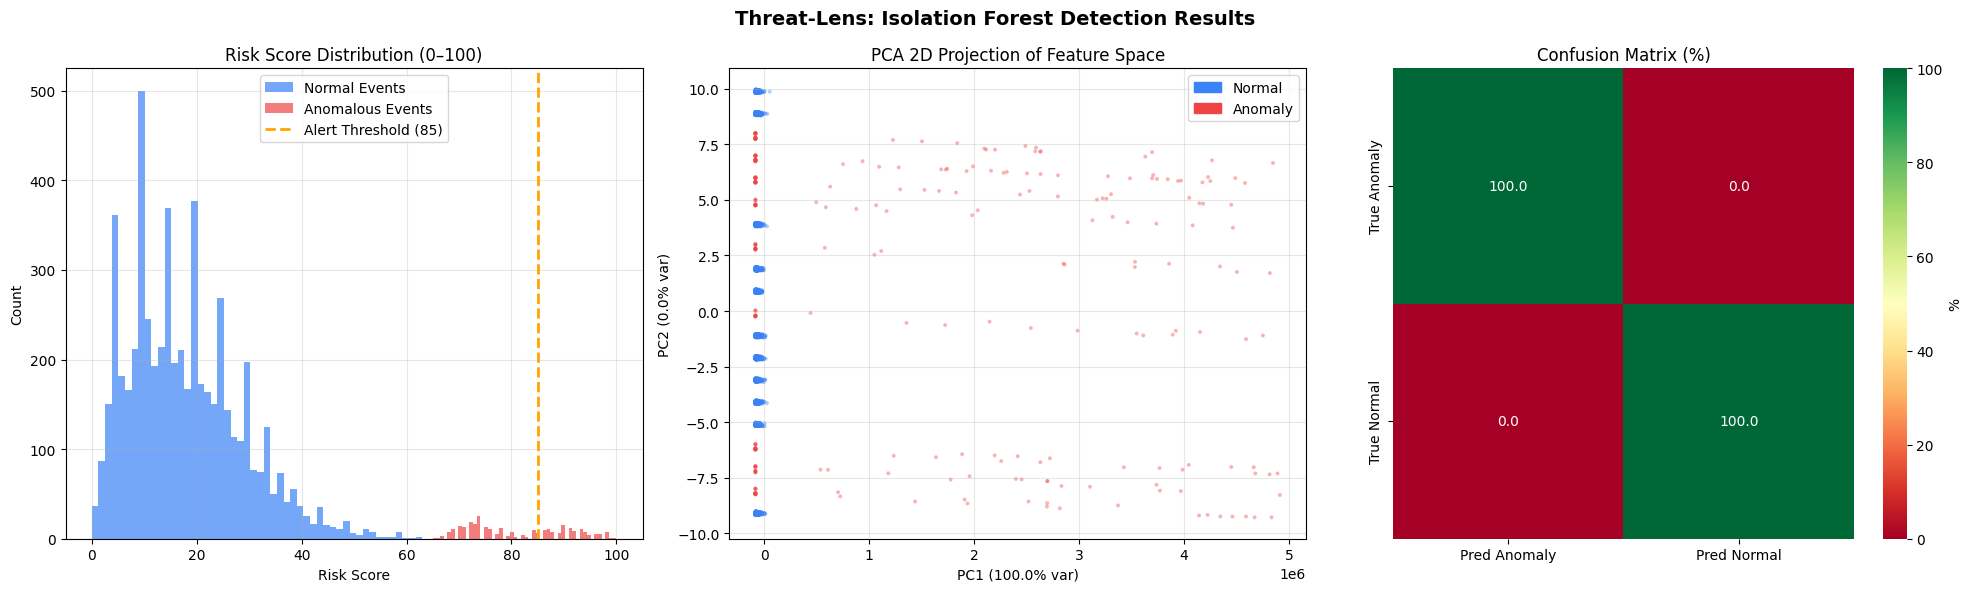

Evaluation chart saved as model_evaluation.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Threat-Lens: Isolation Forest Detection Results', fontsize=14, fontweight='bold')

# ── 1. Risk Score Distribution ──
normal_risks  = df[df['label'] ==  1]['risk_score_0_100']
anomaly_risks = df[df['label'] == -1]['risk_score_0_100']

axes[0].hist(normal_risks,  bins=50, alpha=0.7, color='#3b82f6', label='Normal Events')
axes[0].hist(anomaly_risks, bins=50, alpha=0.7, color='#ef4444', label='Anomalous Events')
axes[0].axvline(85, color='orange', linestyle='--', linewidth=2, label='Alert Threshold (85)')
axes[0].set_title('Risk Score Distribution (0–100)')
axes[0].set_xlabel('Risk Score'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(alpha=0.3)

# ── 2. PCA 2D Projection ──
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X)

scatter_colors = np.where(df['label'] == 1, '#3b82f6', '#ef4444')
axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                c=scatter_colors, alpha=0.4, s=8, linewidths=0)
patch_n = mpatches.Patch(color='#3b82f6', label='Normal')
patch_a = mpatches.Patch(color='#ef4444', label='Anomaly')
axes[1].legend(handles=[patch_n, patch_a])
axes[1].set_title('PCA 2D Projection of Feature Space')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[1].grid(alpha=0.3)

# ── 3. Confusion Matrix Heatmap ──
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=['Pred Anomaly', 'Pred Normal'],
            yticklabels=['True Anomaly', 'True Normal'],
            ax=axes[2], cbar_kws={'label': '%'})
axes[2].set_title('Confusion Matrix (%)')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation chart saved as model_evaluation.png')

## 9. Live Inference Demo
Simulate exactly what happens when the FastAPI backend calls the model on a new event.

In [ ]:
def score_event(action: str, geo: str, amount_inr: float, is_business_hours: bool, hour: int):
    """
    Replicates the exact inference logic in main.py.
    Returns: (is_anomaly: bool, risk_score: int, raw_score: float)
    """
    action_code = le_action.transform([action])[0] if action in le_action.classes_ else -1
    geo_code    = le_geo.transform([geo])[0]        if geo    in le_geo.classes_    else -1

    features = np.array([[amount_inr, int(is_business_hours), hour, action_code, geo_code]])
    pred     = model.predict(features)[0]      # 1 or -1
    raw      = model.decision_function(features)[0]

    # Mirror the risk bonus from main.py
    ml_risk_bonus = int(30 + abs(raw) * 20) if pred == -1 else 0
    is_anomaly    = pred == -1

    return is_anomaly, ml_risk_bonus, raw


# ── Test Cases ──
test_cases = [
    {
        'name':              '✅ Normal: morning login from Mumbai',
        'action':            'LOGIN_SUCCESS',
        'geo':               'Mumbai, MH',
        'amount_inr':        5000.0,
        'is_business_hours': True,
        'hour':              10,
    },
    {
        'name':              '✅ Normal: loan status check from Delhi',
        'action':            'LOAN_STATUS_CHECK',
        'geo':               'Delhi, DL',
        'amount_inr':        0.0,
        'is_business_hours': True,
        'hour':              14,
    },
    {
        'name':              '🚨 ANOMALY: CRM bulk export at 2am from Moscow',
        'action':            'BULK_EXPORT',
        'geo':               'Moscow, RU',
        'amount_inr':        0.0,
        'is_business_hours': False,
        'hour':              2,
    },
    {
        'name':              '🚨 ANOMALY: Unauthorised trade from Dubai at midnight',
        'action':            'UNAUTHORIZED_TRADE',
        'geo':               'Dubai, UAE',
        'amount_inr':        4500000.0,
        'is_business_hours': False,
        'hour':              23,
    },
    {
        'name':              '🚨 ANOMALY: Large attachment from Beijing off-hours',
        'action':            'SEND_LARGE_ATTACHMENT_EXTERNAL',
        'geo':               'Beijing, CN',
        'amount_inr':        0.0,
        'is_business_hours': False,
        'hour':              3,
    },
    {
        'name':              '✅ Normal: Treasury bond query from Bangalore',
        'action':            'BOND_QUERY',
        'geo':               'Bangalore, KA',
        'amount_inr':        250000.0,
        'is_business_hours': True,
        'hour':              11,
    },
]

print('=' * 65)
print('THREAT-LENS ISOLATION FOREST — LIVE INFERENCE DEMO')
print('=' * 65)
print()

for tc in test_cases:
    is_anom, ml_bonus, raw = score_event(
        tc['action'], tc['geo'], tc['amount_inr'],
        tc['is_business_hours'], tc['hour']
    )
    verdict = 'ANOMALY DETECTED' if is_anom else 'NORMAL'
    print(f"{tc['name']}")
    print(f"  ML Verdict:      {verdict}")
    print(f"  ML Risk Bonus:   +{ml_bonus} pts  (raw score: {raw:.4f})")
    print(f"  Action: {tc['action']} | Geo: {tc['geo']} | Hour: {tc['hour']:02d}:00")
    print()

THREAT-LENS ISOLATION FOREST — LIVE INFERENCE DEMO

✅ Normal: morning login from Mumbai
  ML Verdict:      NORMAL
  ML Risk Bonus:   +0 pts  (raw score: 0.1824)
  Action: LOGIN_SUCCESS | Geo: Mumbai, MH | Hour: 10:00

✅ Normal: loan status check from Delhi
  ML Verdict:      NORMAL
  ML Risk Bonus:   +0 pts  (raw score: 0.2114)
  Action: LOAN_STATUS_CHECK | Geo: Delhi, DL | Hour: 14:00

🚨 ANOMALY: CRM bulk export at 2am from Moscow
  ML Verdict:      ANOMALY DETECTED
  ML Risk Bonus:   +31 pts  (raw score: -0.0625)
  Action: BULK_EXPORT | Geo: Moscow, RU | Hour: 02:00

🚨 ANOMALY: Unauthorised trade from Dubai at midnight
  ML Verdict:      ANOMALY DETECTED
  ML Risk Bonus:   +32 pts  (raw score: -0.1257)
  Action: UNAUTHORIZED_TRADE | Geo: Dubai, UAE | Hour: 23:00

🚨 ANOMALY: Large attachment from Beijing off-hours
  ML Verdict:      ANOMALY DETECTED
  ML Risk Bonus:   +30 pts  (raw score: -0.0334)
  Action: SEND_LARGE_ATTACHMENT_EXTERNAL | Geo: Beijing, CN | Hour: 03:00

✅ Normal: Tre

## 10. Save Model Artefacts
Saves to `ml_engine/models/` — the exact path that `main.py` loads from on startup.

In [ ]:
# ── Create output directory ──
OUTPUT_DIR = os.path.join('..', 'ml_engine', 'models')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Save artefacts ──
joblib.dump(model,     os.path.join(OUTPUT_DIR, 'isolation_forest.pkl'))
joblib.dump(le_action, os.path.join(OUTPUT_DIR, 'le_action.pkl'))
joblib.dump(le_geo,    os.path.join(OUTPUT_DIR, 'le_geo.pkl'))

# ── Save the training dataset for audit/reproducibility ──
df.to_csv(os.path.join(OUTPUT_DIR, 'training_data.csv'), index=False)

print('Model artefacts saved:')
for fname in ['isolation_forest.pkl', 'le_action.pkl', 'le_geo.pkl', 'training_data.csv']:
    fpath = os.path.join(OUTPUT_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {fpath:50s}  ({size_kb:.1f} KB)')

print()
print('Training pipeline complete. The Threat-Lens API will load these on startup.')
print(f'  action classes: {list(le_action.classes_)}')
print(f'  geo classes:    {list(le_geo.classes_)}')

Model artefacts saved:
  ..\ml_engine\models\isolation_forest.pkl            (2636.4 KB)
  ..\ml_engine\models\le_action.pkl                   (2.7 KB)
  ..\ml_engine\models\le_geo.pkl                      (0.7 KB)
  ..\ml_engine\models\training_data.csv               (430.7 KB)

Training pipeline complete. The Threat-Lens API will load these on startup.
  action classes: ['BOND_QUERY', 'BULK_EXPORT', 'BULK_LOAN_EXPORT', 'BULK_POSITION_EXPORT', 'CUSTOMER_SEARCH', 'DISBURSEMENT_VIEW', 'DOMESTIC_TRANSFER', 'LOAN_STATUS_CHECK', 'LOGIN_SUCCESS', 'MASS_RECORD_ACCESS', 'POSITION_VIEW', 'RATE_CHECK', 'RATE_MANIPULATION_QUERY', 'SEND_EMAIL', 'SEND_LARGE_ATTACHMENT_EXTERNAL', 'UNAUTHORIZED_API_CALL', 'UNAUTHORIZED_DISBURSEMENT', 'UNAUTHORIZED_TRADE', 'UPDATE_RECORD', 'VIEW_RECORD']
  geo classes:    ['Bangalore, KA', 'Beijing, CN', 'Delhi, DL', 'Dubai, UAE', 'Lagos, NG', 'Moscow, RU', 'Mumbai, MH']


## 11. Feature Importance via Permutation Analysis
Isolation Forest doesn't have built-in feature importance, so we measure each feature's contribution by permuting it and measuring the increase in anomaly score variance.

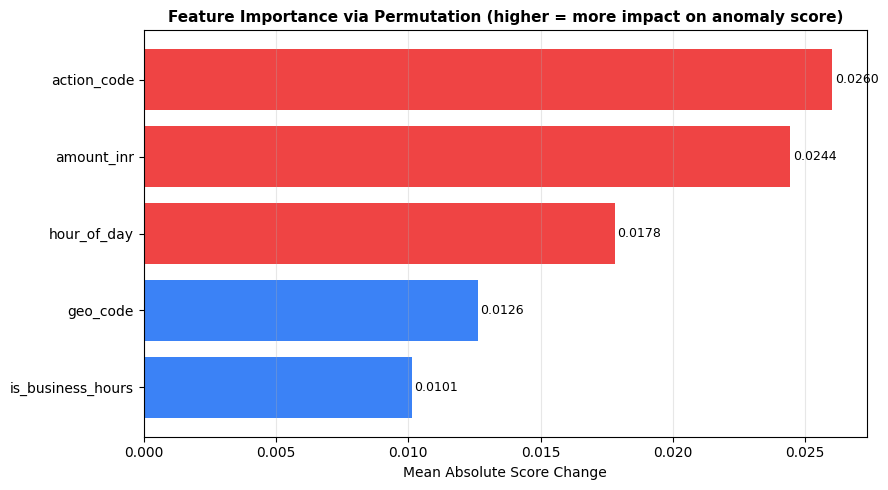

Feature Importance:
  action_code           : 0.0260
  amount_inr            : 0.0244
  hour_of_day           : 0.0178
  geo_code              : 0.0126
  is_business_hours     : 0.0101


In [ ]:
base_scores = model.decision_function(X)
importances = {}

for i, feat in enumerate(FEATURES):
    X_permuted = X.copy()
    np.random.shuffle(X_permuted[:, i])
    perm_scores = model.decision_function(X_permuted)
    # Importance = how much the score changes when this feature is randomised
    importances[feat] = np.mean(np.abs(base_scores - perm_scores))

imp_df = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance'])
imp_df = imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(imp_df['Feature'], imp_df['Importance'],
               color=['#3b82f6' if v < imp_df['Importance'].median() else '#ef4444'
                      for v in imp_df['Importance']])
ax.set_title('Feature Importance via Permutation (higher = more impact on anomaly score)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Mean Absolute Score Change')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, imp_df['Importance']):
    ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature Importance:')
for _, row in imp_df.sort_values('Importance', ascending=False).iterrows():
    print(f'  {row["Feature"]:22s}: {row["Importance"]:.4f}')

## Summary

| Artefact | Purpose |
|---|---|
| `isolation_forest.pkl` | Trained model — loaded by FastAPI on startup |
| `le_action.pkl` | Action label encoder — encodes live event actions |
| `le_geo.pkl` | Geo label encoder — encodes live event locations |
| `training_data.csv` | Labelled dataset — reproducibility & audit |

**Model architecture:** Isolation Forest, 200 trees, 5% contamination, 5 features  
**Monitored systems:** CORE_BANKING, CRM, TREASURY, LOANS, EMAIL  
**Risk scoring:** ML anomaly score maps to 0–100 risk bonus added to rule-engine base score  
**Alert threshold:** Risk ≥ 85 → `is_anomaly = True` → XAI narrative generated via Gemini